A Pendulum Simulation

In [240]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib import animation

Position confined to some 1D path: $x = x(\theta)$ and $y = y(\theta)$ A few examples 

$Parabola: x = \theta$ , $y = \theta^2 \ 
Simple\ Pendulum: x = \cos(\theta)\ and\ y = \sin(\theta) \\
Tautochrone:\ x = \sin(2\theta) + 2\theta \ and\ y = 1 - \cos(2\theta) \\
Many more...$

$
Kinetic\ Energy,\ T = \frac{1}{2} m(\dot{x}^2 + \dot{y}^2) \\ 
Potential\ Energy,\ V = mgy \\
The\ Lagrangian:\ L = T - V \\
Langranges\ Equation:\ \frac{\partial L}{\partial \theta} - \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta}} \right) = 0
$

In [241]:
t, m, g = smp.symbols('t m g')
the = smp.symbols(r'\theta', cls=smp.Function)
the = the(t)
the_d = smp.diff(the, t)
the_dd = smp.diff(the_d, t)

In [242]:
x, y = smp.symbols('x y', cls=smp.Function)
x = x(the)
y = y(the)

In [243]:
path = 'taut'

if path == 'para':
    x = the
    y = the**2
    x_f = smp.lambdify(the, x)
    y_f = smp.lambdify(the, y)

if path =='simPen':
    x = smp.cos(the)
    y = smp.sin(the)
    x_f = smp.lambdify(the, x)
    y_f = smp.lambdify(the, y)

if path == 'taut':
    x = smp.sin(2*the) + 2*the
    y = 1 - smp.cos(2*the)
    x_f = smp.lambdify(the, x)
    y_f = smp.lambdify(the, y)

In [244]:
T = 1/2 * m * (smp.diff(x, t)**2 + smp.diff(y, t)**2)
V = m * g * y
L = T - V

In [245]:
L

-g*m*(1 - cos(2*\theta(t))) + 0.5*m*((2*cos(2*\theta(t))*Derivative(\theta(t), t) + 2*Derivative(\theta(t), t))**2 + 4*sin(2*\theta(t))**2*Derivative(\theta(t), t)**2)

In [246]:
LE = smp.diff(L, the) - smp.diff(smp.diff(L, the_d), t)
LE = LE.simplify()

In [247]:
LE

m*(-2.0*g*sin(2*\theta(t)) + 8.0*sin(2*\theta(t))*Derivative(\theta(t), t)**2 - 8.0*cos(2*\theta(t))*Derivative(\theta(t), (t, 2)) - 8.0*Derivative(\theta(t), (t, 2)))

Solving for $\frac{d^2\theta}{dt^2}$

In [248]:
# 11:50
derive_1 = the_d #omege
derive_2 = smp.solve(LE, the_dd)[0]

In [249]:
derive_1f = smp.lambdify(the_d, the_d)
derive_2f = smp.lambdify((g, the, the_d), derive_2)

$S = (\theta, \omega)$

In [250]:
def dSdt(S, t):
    return [
        derive_1f(S[1]), #dtheta/dt
        derive_2f(g, S[0], S[1]) #domega/dt
    ]

In [251]:
t = np.linspace(0, 20, 1000)
g = 9.81
# ans1 = odeint(dSdt, y0=[2, 0], t=t)
# ans2 = odeint(dSdt, y0=[3, 0], t=t)
ans1 = odeint(dSdt, y0=[np.pi/4, 0], t=t)
ans2 = odeint(dSdt, y0=[np.pi/5, 0], t=t)

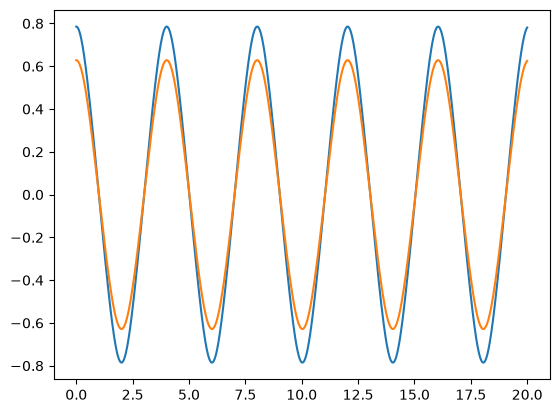

In [252]:
plt.plot(t, ans1.T[0])
plt.plot(t, ans2.T[0])

In [253]:
def get_xy(theta):
    return x_f(theta), y_f(theta)

In [254]:
x1, y1 = get_xy(ans1.T[0])
x2, y2 = get_xy(ans2.T[0])

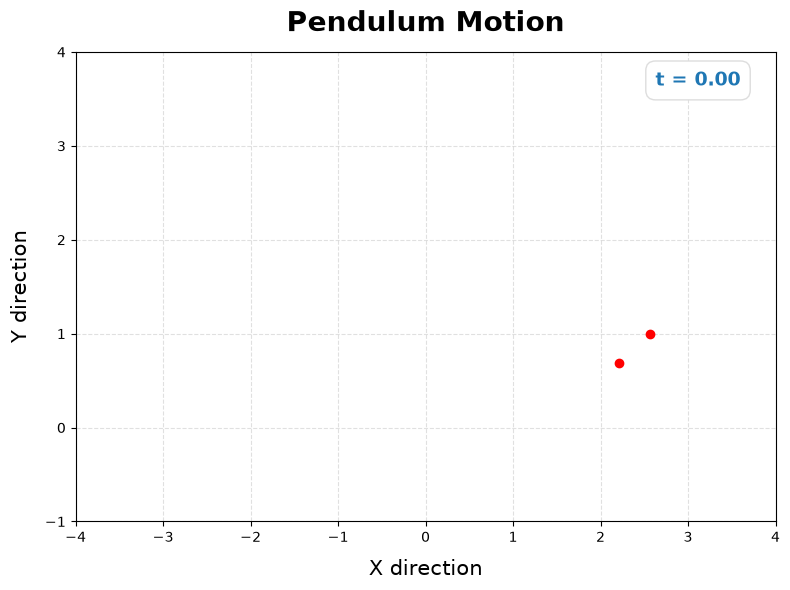

In [ ]:
def animate(i):
    ln1.set_data([x1[i]], [y1[i]])
    ln2.set_data([x2[i]], [y2[i]])
    time_text.set_text('t = {:.2f}'.format(i/50))

fig, ax = plt.subplots(1, 1, figsize=(8,6), layout='tight')
ax.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
ax.set_ylim(-1, 4)
ax.set_xlim(-4, 4)

time_text = ax.text(
    0.95, 0.96, '',
    fontsize = 14,
    fontweight = 'bold',
    fontfamily = 'sans-serif',
    color='#1f77b4',
    transform=ax.transAxes,
    ha='right',
    va = 'top',
    bbox=dict(facecolor='white', edgecolor='#dddddd', boxstyle='round,pad=0.5')
)
plt.title('Pendulum Motion', fontsize=20, fontweight='bold', pad=15)
plt.xlabel('X direction', fontsize=15, labelpad=10)
plt.ylabel('Y direction', fontsize=15, labelpad=10)

ln1, = plt.plot([], [], 'ro')
ln2, = plt.plot([], [], 'ro')

ani = animation.FuncAnimation(fig, animate, frames=1000, interval=50)
ani.save('pen.gif', writer='pillow', fps=50)

In [260]:
# The exact gif file is available as media/pen.gif